# Laboratory #4: Adversarial Learning and OOD Detection

In this laboratory session we will develop a methodology for detecting OOD samples and measuring the quality of OOD detection. We will also experiment with incorporating adversarial examples during training to render models more robust to adversarial attacks.

---
## Exercise 1: OOD Detection and Performance Evaluation
In this first exercise you will build a simple OOD detection pipeline and implement some performance metrics to evaluate its performance.

### Exercise 1.1: Build a simple OOD detection pipeline

Implement an OOD detection pipeline (like in the Flipped Activity notebook) using an ID and an OOD dataset of your choice. Some options:

+ CIFAR-10 (ID), Subset of CIFAR-100 (OOD). You will need to wrap CIFAR-100 in some way to select a subset of classes that are *not* in CIFAR-10 (see `torch.utils.data.Subset`).
+ Labeled Faces in the Wild (ID), CIFAR-10 or FakeData (OOD). The LfW dataset is available in Scikit-learn (see `sklearn.datasets.fetch_lfw_people`).
+ Something else, but if using images keep the images reasonably small!

In this exercise your *OOD Detector* should produce a score representing how "out of distribution" a test sample is. We will implement some metrics in the next exercise, but for now use the techniques from the flipped activity notebook to judge how well OOD scoring is working (i.e. histograms).

**Note**: Make sure you make a validation split of your ID dataset for testing.

#### Imports generali

In [1]:
import random
import torch
import torchinfo
from PIL import features
from torchvision.datasets import CIFAR10, CIFAR100
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.models import list_models, get_model
from torch import nn
from torch import optim
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import pandas as pd
import torchvision

seed = 123

#### Funzioni Utils

Funzione per configurare il file yaml e restituisce i parametri per la configurazione

In [2]:
from types import SimpleNamespace
import yaml
import argparse

# funzione che quando viene richiamata restituisce i parametri di configurazione
def configurer():
    parser = argparse.ArgumentParser()
    parser.add_argument("config", help='YAML Configuration file')
    opts = yaml.load(open(parser.parse_args().config), Loader=yaml.Loader)
    opts = SimpleNamespace(**opts)
    opts.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(opts.device) # per sicurezza per vedere se non succede qualcosa alla gpu
    return opts

Funzione per il logging per eventuale training

In [3]:
from rich.logging import RichHandler
import logging



def get_logger():
    FORMAT = "%(message)s"
    logging.basicConfig(
        level="NOTSET", format=FORMAT, datefmt="[%X]", handlers=[RichHandler()]
    )
    log = logging.getLogger("rich")

    # Silenzia i log verbosi di librerie esterne
    logging.getLogger("matplotlib").setLevel(logging.WARNING)
    logging.getLogger("PIL").setLevel(logging.WARNING)

    return log


#LOG = get_logger()

Funzioni per ottenere le predizioni e creare la matrice di confusione delle previsioni del modello

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def get_predictions(model, dl, device):
    model.eval()
    preds, gts = [], []
    for xs, ys in dl:
        xs = xs.to(device)
        pred = torch.argmax(model(xs), dim=1)
        preds.append(pred.cpu().numpy())
        gts.append(ys.numpy())
    return np.hstack(gts), np.hstack(preds)


def plot_confusion_matrix(model, dl, device, class_names, title="Confusion Matrix"):
    gts, preds = get_predictions(model, dl, device)
    cm = confusion_matrix(gts, preds)

    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return cm

Funzione per visualizzare immagini dataset

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

def show_dataset_samples(dataset, n=8, class_names=None, random_sample=True):
    """
    Mostra n immagini "grezze" da un dataset con il nome della classe sotto ciascuna.

    Args:
        dataset: dataset PyTorch (es. CIFAR10, CIFAR100)
        n: numero di immagini da mostrare
        class_names: lista dei nomi delle classi. Se None, la recupera da dataset.classes
        random_sample: se True, sceglie n immagini a caso; se False, prende le prime n
    """
    if class_names is None:
        if hasattr(dataset, "classes"):
            class_names = dataset.classes
        elif hasattr(dataset, "dataset") and hasattr(dataset.dataset, "classes"):
            class_names = dataset.dataset.classes
        else:
            raise ValueError("Impossibile determinare i nomi delle classi, passa class_names esplicitamente.")

    total = len(dataset)
    indices = random.sample(range(total), n) if random_sample else list(range(n))

    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        ax.imshow(img)
        ax.set_title(class_names[label], fontsize=10)
        ax.axis("off")

    for ax in axes[len(indices):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Funzione per la visulazzazione struttura del modello e numero di parametri

In [6]:
from torchinfo import summary
from rich.console import Console
console = Console()

def visualize(model, model_name, input_data):
    out = model(input_data)
    console.print(f'Computed output, shape = {out.shape=}')
    model_stats = summary(model,
                          input_data=input_data,
                          col_names=[
                              "input_size",
                              "output_size",
                              "num_params",
                          ],
                          row_settings=("var_names",),
                          col_width=18,
                          depth=8,
                          verbose=0,
                          )
    console.print(model_stats)

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
device

'cuda'

#### Creiamo i dataset e i dataloader che ci interessano

vedere se riesco a risolvere questo problema... Ci mette 1h per scaricare 2 dataset altrimenti passerei a usare hugging face (_fixed problems with torchvision_)

In [9]:
# from datasets import load_dataset
#
# cifar10_hf  = load_dataset("uoft-cs/cifar10")
# cifar100_hf = load_dataset("uoft-cs/cifar100")
#
# print(cifar10_hf)
# print(cifar100_hf)
#
# # .features["<col>"] è un oggetto ClassLabel, che espone .names (lista ordinata per indice)
# cifar10_classes  = cifar10_hf["train"].features["label"].names
# cifar100_classes = cifar100_hf["train"].features["fine_label"].names
#
# # Ricostruisco l'equivalente di class_to_idx
# cifar10_class_to_idx  = {name: idx for idx, name in enumerate(cifar10_classes)}
# cifar100_class_to_idx = {name: idx for idx, name in enumerate(cifar100_classes)}
#
# print("Cifar10: ", cifar10_class_to_idx )
# print("\n")
# print("Cifar100", cifar100_class_to_idx)

Presenta problemi scaricarli dai canali ufficiali rispetto a prenderli da hugging face tempi eccessivamente lunghi

In [10]:
cifa10dt = CIFAR10("./data", train=True, download=True)
cifa100dt = CIFAR100("./data", train=True, download=True)
print(f"Cifar10", cifa10dt)
print(f"Cifar100", cifa100dt)

Cifar10 Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
Cifar100 Dataset CIFAR100
    Number of datapoints: 50000
    Root location: ./data
    Split: Train


In [11]:
print("Cifar10: ", cifa10dt.class_to_idx)
print("\n")
print("Cifar100", cifa100dt.class_to_idx)

Cifar10:  {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


Cifar100 {'apple': 0, 'aquarium_fish': 1, 'baby': 2, 'bear': 3, 'beaver': 4, 'bed': 5, 'bee': 6, 'beetle': 7, 'bicycle': 8, 'bottle': 9, 'bowl': 10, 'boy': 11, 'bridge': 12, 'bus': 13, 'butterfly': 14, 'camel': 15, 'can': 16, 'castle': 17, 'caterpillar': 18, 'cattle': 19, 'chair': 20, 'chimpanzee': 21, 'clock': 22, 'cloud': 23, 'cockroach': 24, 'couch': 25, 'crab': 26, 'crocodile': 27, 'cup': 28, 'dinosaur': 29, 'dolphin': 30, 'elephant': 31, 'flatfish': 32, 'forest': 33, 'fox': 34, 'girl': 35, 'hamster': 36, 'house': 37, 'kangaroo': 38, 'keyboard': 39, 'lamp': 40, 'lawn_mower': 41, 'leopard': 42, 'lion': 43, 'lizard': 44, 'lobster': 45, 'man': 46, 'maple_tree': 47, 'motorcycle': 48, 'mountain': 49, 'mouse': 50, 'mushroom': 51, 'oak_tree': 52, 'orange': 53, 'orchid': 54, 'otter': 55, 'palm_tree': 56, 'pear': 57, 'pickup_truck': 58, 'pine_tree': 59, 'plain

### EDA
Vediamo il numero di esempi per ogni classe

In [12]:
train_labels = cifa10dt.targets

# conteggio degli elementi per classe (train)
df = pd.DataFrame({
    "Class": cifa10dt.classes,  # lista ordinata per indice, es. ['airplane', 'automobile', ...]
    "N_Images": pd.Series(train_labels).value_counts().sort_index().values,
})

In [13]:
df

,Class,N_Images
0,airplane,5000
1,automobile,5000
2,bird,5000
3,cat,5000
4,deer,5000
5,dog,5000
6,frog,5000
7,horse,5000
8,ship,5000
9,truck,5000


<Axes: >

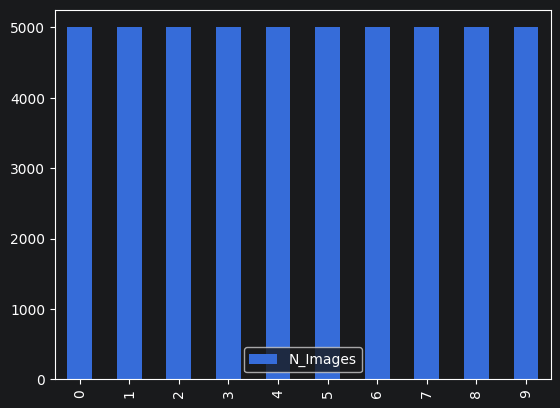

In [14]:
df.plot.bar()

Vediamo degli esempi di immagini sia per cifar10 e cifar100

Cifar10

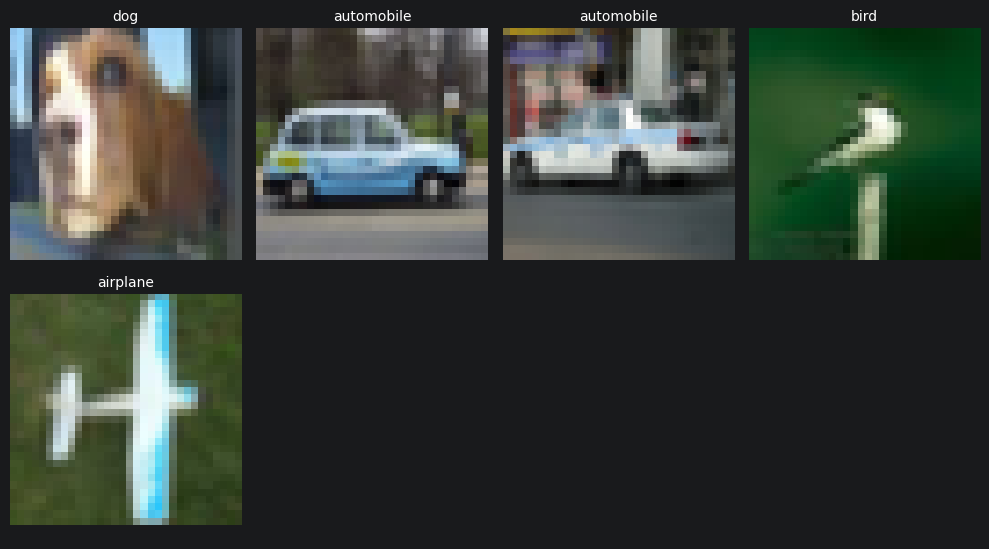

In [15]:
show_dataset_samples(cifa10dt, 8)

Cifar100

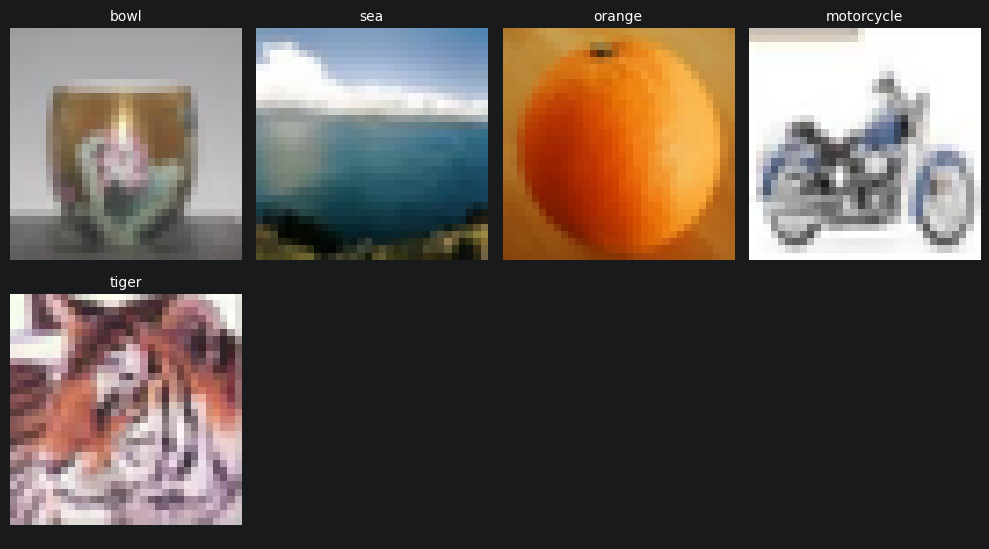

In [16]:
show_dataset_samples(cifa100dt, 8)

Creiamo una classe dataset da wrapper per gestire i dati da i dataset di HF (_fixed problem with torchvision_)

In [17]:
# from torch.utils.data import Dataset
# import torchvision.transforms.v2 as T
#
# class CifarDataset(Dataset):
#     def __init__(self, opts, data, img_col, label_col, transform=None):
#         self.opts = opts
#         self.data = data
#         self.img_col = img_col
#         self.label_col = label_col
#         if transform is None:
#             self.transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
#
#     def __len__(self):
#         return len(self.data)
#
#     def __getitem__(self, idx):
#         features = self.data[idx]
#         labels = features[self.label_col]
#         images = features[self.img_col]
#         images = self.transform(images)
#
#         return {"images": images, "labels": labels}


Creiamo i dataloader (_fixed problem with torchvision_)

In [18]:
# from torch.utils.data import DataLoader
#
# class MakeDataLoader:
#     def __init__(self, opts, HFdata, img_col, label_col, transform=None):
#         self.opts = opts
#         self.HFdata = HFdata
#
#         generator = torch.Generator().manual_seed(opts.seed)
#
#         train_dt = CifarDataset(opts, HFdata["train"], img_col, label_col, transform=transform)
#
#         train, val = torch.utils.data.random_split(train_dt, lengths=[1 - opts.val_size, opts.val_size],
#                                                     generator=generator)
#         self.train_dl = DataLoader(train, batch_size=opts.batch_size, shuffle=True, num_workers=opts.num_workers)
#         self.val_dl = DataLoader(val, batch_size=opts.batch_size, shuffle=False, num_workers=opts.num_workers)
#
#         test_dt = CifarDataset(opts, HFdata["test"], img_col, label_col)
#         self.test_dl = DataLoader(test_dt, batch_size=opts.batch_size, shuffle=False, num_workers=opts.num_workers)



Funzione per liberare memoria dalla GPU

In [19]:
import gc

def free_gpu_memory(*objects):
    """
    Elimina esplicitamente gli oggetti passati e libera la cache GPU.
    Esempio: free_gpu_memory(model, optimizer, backbone)
    """
    for obj in objects:
        del obj
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()  # aspetta che tutte le operazioni CUDA pendenti finiscano

Funzione per caricare un checkpoint

In [20]:
def load_checkpoint(model: nn.Module, checkpoint_path: str, device="cpu") -> nn.Module:
    """
    Carica i pesi (state_dict) salvati all'interno di un modello PyTorch.

    Args:
        model: L'istanza dell'architettura del modello vuota (es. SimpleCNN()).
        checkpoint_path: Il percorso del file .pth (es. 'SimpleCNN_best.pth').
        device: 'cpu' o 'cuda', per mappare correttamente i pesi.

    Returns:
        Il modello con i pesi caricati, già impostato in modalità eval().
    """
    # 1. Controllo di sicurezza sull'esistenza del file
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"️ Impossibile trovare il checkpoint: {checkpoint_path}. Assicurati che il nome sia corretto.")

    # 2. Caricamento del dizionario dei pesi
    # map_location=device è cruciale: permette di caricare su CPU un modello allenato su GPU (e viceversa) senza crash.
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)

    # 3. Iniezione dei pesi nel modello
    model.load_state_dict(state_dict)

    # 4. Spostamento sul device corretto e setup per l'inferenza
    model = model.to(device)
    model.eval() # Fondamentale: spegne il Dropout e blocca le BatchNorm in modalità test

    print(f"Checkpoint '{checkpoint_path}' caricato con successo sul device: {device}")

    return model

Creiamo le funzioni transform (vorrei trattare Vit, CNN casuale, ResNet18)

In [21]:
ViT_transform = transforms.Compose( # pretrained resnet (torchvision)
    [transforms.Resize(224),
    transforms.ToTensor(),
     transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))])

CNNtransform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

ResNet_transform =transforms.Compose( # pretrained resnet (torchvision)
    [transforms.Resize(224),
    transforms.ToTensor(),
     transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))])

Creiamo una Semplice CNN

In [22]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x): # [B, 3, 32, 32] [B, C, H, W]
        # Primo blocco convoluzionale
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x) # Riduce a [B, 64, 16, 16]

        # Secondo blocco convoluzionale
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x) # Riduce a [B, 256, 8, 8]

        # Classificatore
        x = self.gap(x) # [B, 256, 1, 1]
        x = self.flatten(x) # [B, 256]
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x



Creiamo la funzione di training/finetuning

In [23]:
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
import torch.nn.functional as F
import torch
import numpy as np
from torch.utils.tensorboard import SummaryWriter
import os

torch.backends.cudnn.benchmark = True

def train_epoch(model, dl, optimizer, scaler, epoch="Unknown", device="cpu"):
    model.train()
    losses = []
    correct = 0
    total = 0

    for (xs, ys) in tqdm(dl, desc=f"Epoch {epoch}", leave=True):
        xs = xs.to(device, non_blocking=True)
        ys = ys.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device == "cuda")):
            out = model(xs)
            loss = F.cross_entropy(out, ys)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item())

        # accuracy sui batch di training (usando le predizioni già calcolate)
        preds = torch.argmax(out, dim=1)
        correct += (preds == ys).sum().item()
        total += ys.size(0)

    train_acc = correct / total
    return np.mean(losses), train_acc

@torch.no_grad()
def evaluate_model(model: nn.Module, dl: torch.utils.data.DataLoader , device="cpu"):
    model.eval()
    preds = []
    gts = []
    with torch.no_grad():
        for (xs, ys) in tqdm(dl, desc=f"Evaluating", leave=False):
            xs = xs.to(device)
            pred = torch.argmax(model(xs), dim=1)
            gts.append(ys)
            preds.append(pred.detach().cpu().numpy())

        #return accuracy score and classification report
        return (accuracy_score(np.hstack(gts), np.hstack(preds))), classification_report(np.hstack(gts), np.hstack(preds), zero_division=0, digits=1)


def main_train(model: nn.Module, dl_train: torch.utils.data.DataLoader, dl_val: torch.utils.data.DataLoader, epochs: int, model_name: str, image_size: int, batch_size: int, lr: float = 1e-3, device="cpu"):
    # 1. Setup Logger e TensorBoard
    LOG = get_logger()
    writer = SummaryWriter(log_dir=os.path.join("runs", model_name))

    LOG.info(f"Inizializzazione training per il modello: {model_name}")

    # 2. Sposta il modello sul device corretto
    model = model.to(device)

    # 3. Visualizzazione Struttura Modello (CIFAR-10 usa immagini 3x32x32)
    LOG.info("Generazione summary del modello...")
    dummy_input = torch.randn(batch_size, 3, image_size, image_size).to(device)
    visualize(model, model_name, dummy_input)

    # 4. Inizializzazione Ottimizzatore (puoi passarlo come parametro se preferisci)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scaler = torch.amp.GradScaler(enabled=(device == "cuda"))

    best_acc = 0.0

    # 5. Loop di Addestramento
    LOG.info(f"Inizio addestramento per {epochs} epoche sul device: {device}")
    for epoch in range(1, epochs + 1):

        # --- TRAINING ---
        train_loss, acc_tr = train_epoch(model, dl_train, optimizer, scaler, epoch, device)

        # --- VALIDATION ---
        val_acc, val_report = evaluate_model(model, dl_val, device)

        # --- LOGGING TERMINALE (Rich) ---
        LOG.info(f"Epoch {epoch}/{epochs} completata!")
        LOG.info(f"Train Loss: {train_loss:.4f} | Train Accuracy: {acc_tr:.4f} | Val Accuracy: {val_acc:.4f}")

        # --- LOGGING TENSORBOARD ---
        writer.add_scalar("Loss/Train", train_loss, epoch)
        writer.add_scalar("Accuracy/Train", acc_tr, epoch)
        writer.add_scalar("Accuracy/Validation", val_acc, epoch)

        # --- SALVATAGGIO BEST MODEL ---
        if val_acc > best_acc:
            best_acc = val_acc
            save_path = f"{model_name}_best.pth"
            torch.save(model.state_dict(), save_path)
            LOG.info(f"Nuovo best model salvato in {save_path} con accuracy: {best_acc:.4f}")

    # Log Finale del Classification Report per avere un'idea dettagliata delle performance
    LOG.info("\nClassification Report Finale (Best Epochs escluse):\n" + val_report)
    LOG.info("Training concluso! ")


    # Chiudi il writer di TensorBoard
    writer.close()

    # carichiamo il miglior modello
    model.load_state_dict(torch.load(save_path))
    return model



Funzione per ottenere le classi più lontani OOD di CIFAR100 rispetto a CIFAR10

In [24]:
from torch.utils.data import Subset

def get_far_ood_subset(dataset: torchvision.datasets.CIFAR100, classes_to_keep: list) -> Subset:
    """
    Estrae un sottoinsieme (Subset) da un dataset, mantenendo SOLO le classi specificate.
    Far-OOD.

    Args:
        dataset: Il dataset originale (es. CIFAR-100 test set).
        classes_to_keep: Lista di stringhe con i nomi delle classi da conservare.

    Returns:
        Un oggetto torch.utils.data.Subset pronto per essere passato a un DataLoader.
    """
    # 1. Recuperiamo il dizionario interno del dataset che mappa nomi -> numeri
    class_dict = dataset.class_to_idx

    # 2. Convertiamo i nomi in ID numerici (ignorando eventuali nomi scritti male)
    valid_ids = [class_dict[name] for name in classes_to_keep if name in class_dict]

    if not valid_ids:
        raise ValueError("Nessuna delle classi specificate è presente nel dataset!")

    # 3. Estraiamo tutte le etichette originali
    targets = np.array(dataset.targets)

    # 4. Creiamo la maschera logica e troviamo le posizioni esatte da conservare
    mask = np.isin(targets, valid_ids)
    indices_to_keep = np.where(mask)[0].tolist()

    print(f"Filtro applicato: mantenute {len(valid_ids)} classi su 100.")
    print(f"Dimensione dataset originale: {len(targets)} -> Nuovo OOD Subset: {len(indices_to_keep)}")

    # 5. Restituiamo il Subset pacchettizzato
    return Subset(dataset, indices_to_keep)

In [25]:
list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

Funzione di generazione dataloaders ID e OOD

In [26]:
def generate_dataloaders(transform, batch_size= 256, split= 0.3):
    # Dataset training validation testing ID
    ID_train_dt = CIFAR10("./data", train=True, download=True, transform=transform)
    ID_test_dt = CIFAR10("./data", train=False, download=True, transform=transform)

    generator = torch.Generator().manual_seed(seed)
    train, val  = torch.utils.data.random_split(ID_train_dt, lengths=[1 - split, split],  generator=generator)

    ID_tr_dl = DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    ID_val_dl = DataLoader(val, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    ID_ts_dl = DataLoader(ID_test_dt, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    # Dataset testing OOD
    OOD_dt = CIFAR100("./data", train=False, download=True, transform=ViT_transform)

    # scegliamo le classi più lontane da ID e creiamo un Subset

    clean_ood_classes = [
        'orchid', 'poppy', 'rose', 'sunflower', 'tulip',       # Fiori
        'bottle', 'bowl', 'can', 'cup', 'plate',               # Contenitori
        'maple_tree', 'oak_tree', 'palm_tree', 'pine_tree'     # Alberi
    ]

    OOD_dt = get_far_ood_subset(OOD_dt, clean_ood_classes)

    OOD_dl = DataLoader(OOD_dt, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    return {"train": ID_tr_dl, "val": ID_val_dl, "test": ID_ts_dl, "OOD": OOD_dl}

Funzione per generare il modello da finetunare

In [27]:
def get_model_for_cifar10(model_name, device="cpu"):
    model = get_model(model_name, weights="DEFAULT")  # o weights=None per training da zero
    model.to(device)

    # Recupera in_features in base al tipo di modello, e sostituisce l'head con Identity
    if model_name == "resnet18":
        in_features = model.fc.in_features
        model.fc = nn.Identity()

    elif model_name == "vit_b_16":
        in_features = model.heads.head.in_features
        model.heads = nn.Identity()

    # Crea la head MLP
    head = MLPHead(in_features=in_features, num_classes=10, hidden_dim=256, dropout=0.3)

    # Modello finale = backbone + head MLP
    full_model = nn.Sequential(model, head).to(device)
    return full_model

In [28]:
import torch.nn as nn

class MLPHead(nn.Module):
    def __init__(self, in_features, num_classes, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.mlp(x)

---
### Fase di Training-Tuning

In [29]:
# # -----------------------------
# # PARAMETRI
# model_name= "vit_b_16"
# batch_size= 32
# epochs = 10
# lr = 1e-4
# image_size = 224
# #----------------------
#
# data = generate_dataloaders(transform=ViT_transform, batch_size=batch_size, split=0.3)
#
# train_dl = data["train"]
# val_dl = data["val"]
# test_dl = data["test"]
# OOD_dl = data["OOD"]
#
# model = get_model_for_cifar10(model_name, device)
#
# model = main_train(model, train_dl, val_dl, epochs, model_name, image_size,batch_size, lr, device)
#
# test_acc, test_report = evaluate_model(model, test_dl, device)
#
# print(f"Test Accuracy: {test_acc:.4f}\n")
# print(test_report)
#
# free_gpu_memory(model)

# IL ViT non verrà preso in considerazione perché richiede tanto tempo rispetto agli altri modelli per essere finetunato e si ottengono risultati mediocri (test accuracy intorno al 45%)

In [30]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                    'dog', 'frog', 'horse', 'ship', 'truck']

Filtro applicato: mantenute 14 classi su 100.
Dimensione dataset originale: 10000 -> Nuovo OOD Subset: 1400


[21:36:50] INFO     Inizializzazione training per il modello: resnet18                              ]8;id=823480;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=280691;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#61\61]8;;\

           INFO     Generazione summary del modello...                                              ]8;id=481667;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=226741;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#67\67]8;;\

Computed output, shape = out.shape=torch.Size([256, 10])

===================================================================================================
Layer (type (var_name))                       Input Shape        Output Shape       Param #
===================================================================================================
Sequential (Sequential)                       [256, 3, 224, 224] [256, 10]          --
├─ResNet (0)                                  [256, 3, 224, 224] [256, 512]         --
│    └─Conv2d (conv1)                         [256, 3, 224, 224] [256, 64, 112, 112] 9,408
│    └─BatchNorm2d (bn1)                      [256, 64, 112, 112] [256, 64, 112, 112] 128
│    └─ReLU (relu)                            [256, 64, 112, 112] [256, 64, 112, 112] --
│    └─MaxPool2d (maxpool)                    [256, 64, 112, 112] [256, 64, 56, 56]  --
│    └─Sequential (layer1)                    [256, 64, 56, 56]  [256, 64, 56, 56]  --
│    │    └─BasicBlock (0)                    [256, 64, 56, 56]  [256, 64, 56, 56]  --
│    │    │    └─Conv2d (conv1)               [256, 64, 56, 56]  [256, 64, 56, 56]  36,864
│    │    │    └─BatchNorm2d (bn1)            [256, 64, 56, 56]  [256, 64, 56, 56]  128
│    │    │    └─ReLU (relu)                  [256, 64, 56, 56]  [256, 64, 56, 56]  --
│    │    │    └─Conv2d (conv2)               [256, 64, 56, 56]  [256, 64, 56, 56]  36,864
│    │    │    └─BatchNorm2d (bn2)            [256, 64, 56, 56]  [256, 64, 56, 56]  128
│    │    │    └─ReLU (relu)                  [256, 64, 56, 56]  [256, 64, 56, 56]  --
│    │    └─BasicBlock (1)                    [256, 64, 56, 56]  [256, 64, 56, 56]  --
│    │    │    └─Conv2d (conv1)               [256, 64, 56, 56]  [256, 64, 56, 56]  36,864
│    │    │    └─BatchNorm2d (bn1)            [256, 64, 56, 56]  [256, 64, 56, 56]  128
│    │    │    └─ReLU (relu)                  [256, 64, 56, 56]  [256, 64, 56, 56]  --
│    │    │    └─Conv2d (conv2)               [256, 64, 56, 56]  [256, 64, 56, 56]  36,864
│    │    │    └─BatchNorm2d (bn2)            [256, 64, 56, 56]  [256, 64, 56, 56]  128
│    │    │    └─ReLU (relu)                  [256, 64, 56, 56]  [256, 64, 56, 56]  --
│    └─Sequential (layer2)                    [256, 64, 56, 56]  [256, 128, 28, 28] --
│    │    └─BasicBlock (0)                    [256, 64, 56, 56]  [256, 128, 28, 28] --
│    │    │    └─Conv2d (conv1)               [256, 64, 56, 56]  [256, 128, 28, 28] 73,728
│    │    │    └─BatchNorm2d (bn1)            [256, 128, 28, 28] [256, 128, 28, 28] 256
│    │    │    └─ReLU (relu)                  [256, 128, 28, 28] [256, 128, 28, 28] --
│    │    │    └─Conv2d (conv2)               [256, 128, 28, 28] [256, 128, 28, 28] 147,456
│    │    │    └─BatchNorm2d (bn2)            [256, 128, 28, 28] [256, 128, 28, 28] 256
│    │    │    └─Sequential (downsample)      [256, 64, 56, 56]  [256, 128, 28, 28] --
│    │    │    │    └─Conv2d (0)              [256, 64, 56, 56]  [256, 128, 28, 28] 8,192
│    │    │    │    └─BatchNorm2d (1)         [256, 128, 28, 28] [256, 128, 28, 28] 256
│    │    │    └─ReLU (relu)                  [256, 128, 28, 28] [256, 128, 28, 28] --
│    │    └─BasicBlock (1)                    [256, 128, 28, 28] [256, 128, 28, 28] --
│    │    │    └─Conv2d (conv1)               [256, 128, 28, 28] [256, 128, 28, 28] 147,456
│    │    │    └─BatchNorm2d (bn1)            [256, 128, 28, 28] [256, 128, 28, 28] 256
│    │    │    └─ReLU (relu)                  [256, 128, 28, 28] [256, 128, 28, 28] --
│    │    │    └─Conv2d (conv2)               [256, 128, 28, 28] [256, 128, 28, 28] 147,456
│    │    │    └─BatchNorm2d (bn2)            [256, 128, 28, 28] [256, 128, 28, 28] 256
│    │    │    └─ReLU (relu)                  [256, 128, 28, 28] [256, 128, 28, 28] --
│    └─Sequential (layer3)                    [256, 128, 28, 28] [256, 256, 14, 14] --
│    │    └─BasicBlock (0)                    [256, 128, 28, 28] [256, 256, 14, 14] --
│    │    │    └─Conv2d (conv1)               [256, 128, 28, 28] [256, 256, 14, 14] 

...

[21:52:05] INFO     Epoch 10/10 completata!                                                         ]8;id=27035;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=82744;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#88\88]8;;\

           INFO     Train Loss: 0.0498 | Train Accuracy: 0.9831 | Val Accuracy: 0.9013              ]8;id=420640;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=685227;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#89\89]8;;\

           INFO                                                                                    ]8;id=61868;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=701564;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#104\104]8;;\
                    Classification Report Finale (Best Epochs escluse):                                            
                                  precision    recall  f1-score   support                                          
                                                                                                                   
                               0        0.8       1.0       0.9      1490                                          
                               1        0.9       1.0       0.9      1507                                          
                               2        0.9       0.9       0.9      1500                                          
                               3        0.8       0.9       0.8      1490                                          
                               4        0.9       0.9       0.9      1475                                          
                               5        0.9       0.8       0.9      1533                                          
                               6        0.9       1.0       0.9      1468                                          
                               7        0.9       0.9       0.9      1502                                          
                               8        1.0       0.9       0.9      1530                                          
                               9        1.0       0.8       0.9      1505                                          
                                                                                                                   
                        accuracy                            0.9     15000                                          
                       macro avg        0.9       0.9       0.9     15000                                          
                    weighted avg        0.9       0.9       0.9     15000                                          
                                                                                                                   

           INFO     Training concluso!                                                             ]8;id=5408;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=438509;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#105\105]8;;\

Test Accuracy: 0.8981

              precision    recall  f1-score   support

           0        0.9       0.9       0.9      1000
           1        0.9       0.9       0.9      1000
           2        0.9       0.9       0.9      1000
           3        0.8       0.8       0.8      1000
           4        0.9       0.9       0.9      1000
           5        0.9       0.8       0.8      1000
           6        0.9       0.9       0.9      1000
           7        0.9       0.9       0.9      1000
           8        0.9       0.9       0.9      1000
           9        0.9       0.9       0.9      1000

    accuracy                            0.9     10000
   macro avg        0.9       0.9       0.9     10000
weighted avg        0.9       0.9       0.9     10000



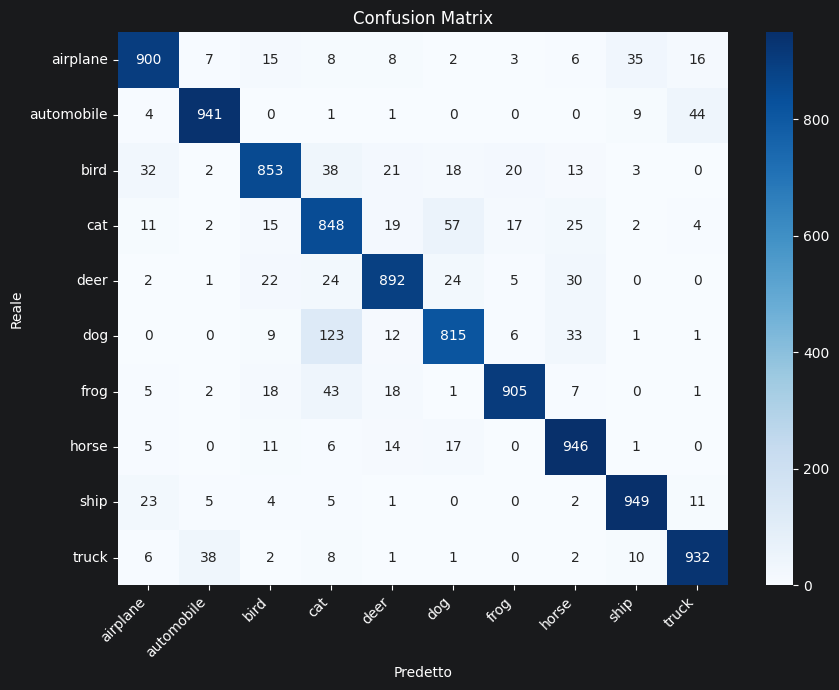

In [31]:
# -----------------------------
# PARAMETRI
model_name= "resnet18"
batch_size= 256
epochs = 10
lr = 1e-3
image_size = 224
#----------------------

data = generate_dataloaders(transform=ResNet_transform, batch_size=batch_size, split=0.3)

train_dl = data["train"]
val_dl = data["val"]
test_dl = data["test"]
OOD_dl = data["OOD"]

model = get_model_for_cifar10(model_name, device)

model = main_train(model, train_dl, val_dl, epochs, model_name, image_size,batch_size, lr, device)

test_acc, test_report = evaluate_model(model, test_dl, device)

print(f"Test Accuracy: {test_acc:.4f}\n")
print(test_report)

plot_confusion_matrix(model, test_dl, device=device, class_names=CIFAR10_CLASSES)

free_gpu_memory(model)

Filtro applicato: mantenute 14 classi su 100.
Dimensione dataset originale: 10000 -> Nuovo OOD Subset: 1400


[21:52:51] INFO     Inizializzazione training per il modello: simplecnn                             ]8;id=415727;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=541186;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#61\61]8;;\

           INFO     Generazione summary del modello...                                              ]8;id=821791;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=526600;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#67\67]8;;\

Computed output, shape = out.shape=torch.Size([128, 10])

==============================================================================================
Layer (type (var_name))                  Input Shape        Output Shape       Param #
==============================================================================================
SimpleCNN (SimpleCNN)                    [128, 3, 32, 32]   [128, 10]          --
├─Conv2d (conv1)                         [128, 3, 32, 32]   [128, 32, 32, 32]  896
├─BatchNorm2d (bn1)                      [128, 32, 32, 32]  [128, 32, 32, 32]  64
├─ReLU (relu)                            [128, 32, 32, 32]  [128, 32, 32, 32]  --
├─Conv2d (conv2)                         [128, 32, 32, 32]  [128, 64, 32, 32]  18,496
├─BatchNorm2d (bn2)                      [128, 64, 32, 32]  [128, 64, 32, 32]  128
├─ReLU (relu)                            [128, 64, 32, 32]  [128, 64, 32, 32]  --
├─MaxPool2d (pool)                       [128, 64, 32, 32]  [128, 64, 16, 16]  --
├─Conv2d (conv3)                         [128, 64, 16, 16]  [128, 128, 16, 16] 73,856
├─BatchNorm2d (bn3)                      [128, 128, 16, 16] [128, 128, 16, 16] 256
├─ReLU (relu)                            [128, 128, 16, 16] [128, 128, 16, 16] --
├─Conv2d (conv4)                         [128, 128, 16, 16] [128, 256, 16, 16] 295,168
├─BatchNorm2d (bn4)                      [128, 256, 16, 16] [128, 256, 16, 16] 512
├─ReLU (relu)                            [128, 256, 16, 16] [128, 256, 16, 16] --
├─MaxPool2d (pool)                       [128, 256, 16, 16] [128, 256, 8, 8]   --
├─AdaptiveAvgPool2d (gap)                [128, 256, 8, 8]   [128, 256, 1, 1]   --
├─Flatten (flatten)                      [128, 256, 1, 1]   [128, 256]         --
├─Linear (fc1)                           [128, 256]         [128, 128]         32,896
├─ReLU (relu)                            [128, 128]         [128, 128]         --
├─Dropout (dropout)                      [128, 128]         [128, 128]         --
├─Linear (fc2)                           [128, 128]         [128, 10]          1,290
==============================================================================================
Total params: 423,562
Trainable params: 423,562
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 14.64
==============================================================================================
Input size (MB): 1.57
Forward/backward pass size (MB): 402.79
Params size (MB): 1.69
Estimated Total Size (MB): 406.06
==============================================================================================

...

[22:11:41] INFO     Epoch 30/30 completata!                                                         ]8;id=989694;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=767693;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#88\88]8;;\

           INFO     Train Loss: 0.1728 | Train Accuracy: 0.9394 | Val Accuracy: 0.7393              ]8;id=648716;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=269367;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#89\89]8;;\

           INFO                                                                                    ]8;id=778898;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=422563;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#104\104]8;;\
                    Classification Report Finale (Best Epochs escluse):                                            
                                  precision    recall  f1-score   support                                          
                                                                                                                   
                               0        0.7       0.9       0.8      1490                                          
                               1        0.9       0.8       0.9      1507                                          
                               2        0.9       0.4       0.6      1500                                          
                               3        0.7       0.5       0.6      1490                                          
                               4        0.5       0.9       0.6      1475                                          
                               5        0.8       0.5       0.7      1533                                          
                               6        0.8       0.8       0.8      1468                                          
                               7        0.7       0.9       0.8      1502                                          
                               8        0.9       0.9       0.9      1530                                          
                               9        1.0       0.7       0.8      1505                                          
                                                                                                                   
                        accuracy                            0.7     15000                                          
                       macro avg        0.8       0.7       0.7     15000                                          
                    weighted avg        0.8       0.7       0.7     15000                                          
                                                                                                                   

           INFO     Training concluso!                                                             ]8;id=836743;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py\631140511.py]8;;\:]8;id=665868;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21684\631140511.py#105\105]8;;\

Test Accuracy: 0.7859

              precision    recall  f1-score   support

           0        0.8       0.8       0.8      1000
           1        0.9       0.9       0.9      1000
           2        0.9       0.5       0.7      1000
           3        0.7       0.7       0.7      1000
           4        0.7       0.8       0.8      1000
           5        0.8       0.7       0.7      1000
           6        0.9       0.8       0.8      1000
           7        0.8       0.9       0.8      1000
           8        0.8       0.9       0.8      1000
           9        0.8       0.9       0.9      1000

    accuracy                            0.8     10000
   macro avg        0.8       0.8       0.8     10000
weighted avg        0.8       0.8       0.8     10000



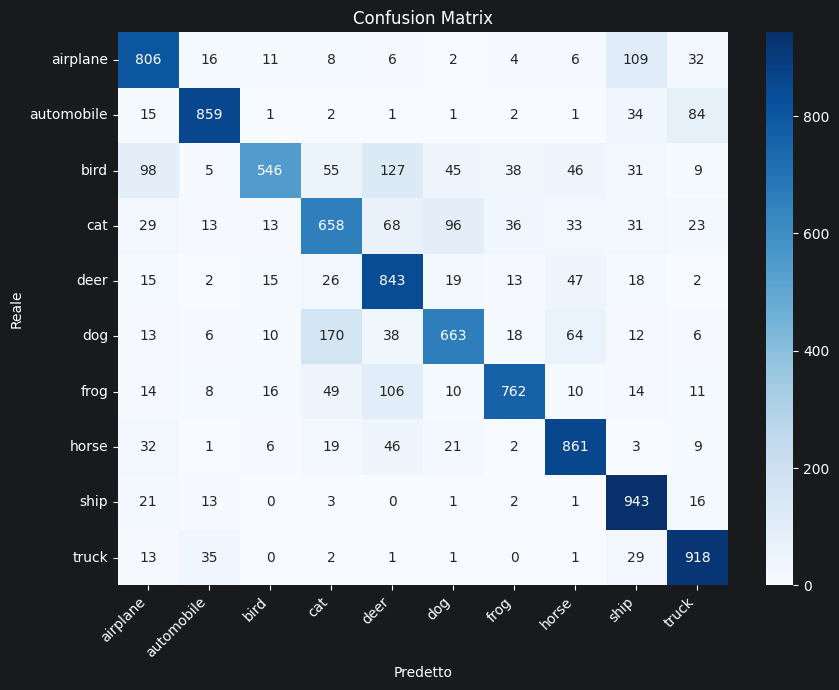

In [32]:
# -----------------------------
# PARAMETRI
model_name= "simplecnn"
batch_size= 128
epochs = 30
lr = 0.01
image_size = 32
#----------------------

data = generate_dataloaders(transform=CNNtransform, batch_size=batch_size, split=0.3)

train_dl = data["train"]
val_dl = data["val"]
test_dl = data["test"]
OOD_dl = data["OOD"]

#model = get_model_for_cifar10(model_name, device)

model = SimpleCNN()

model = main_train(model, train_dl, val_dl, epochs, model_name, image_size,batch_size, lr, device)

test_acc, test_report = evaluate_model(model, test_dl, device)

print(f"Test Accuracy: {test_acc:.4f}\n")
print(test_report)

plot_confusion_matrix(model, test_dl, device=device, class_names=CIFAR10_CLASSES)

free_gpu_memory(model)

### Osservazioni
osservando questi risultati possiamo notare alcune cose:
- **ViT**: non è presente direttamente nel notebook però esiste la pipeline per fare un finetuning semplice tuttavia non verrà preso in considerazione per il continuo per i tempi lunghi di finetuning rispetto agli altri modelli e soprattutto per i risultati scarsi che ho ottenuto su Cifar10 _accuratezza intorno al 45%_
- **ResNet18**: modello torchvision finetunato risulta il miglior modello per la classificazione del dataset Cifar10 raggiungendo nel testing un valore intorno _accuratezza 90%_. Da notare attentamente il modello fatica a identificare la classe cani associandola spesso alla classe gatto.
- **simpleCNN**: modello semplice di CNN creato da me per testare se un modello trainato sul dataset e non finetunato ottenesse risultati migliori cosa che non avviene dato che risulta nella classificazione _un'accuratezza 78%_.

Con una selezione più accurata degli iperparametri si potrebbe ottenere risultati migliori però non è questo l'obiettivo del notebook e quindi per la nostra OOD detection teniamo in considerazione i modelli **ResNet18** **simpleCNN**

**N.B.**: _se si vuole vedere nel dettaglio il training e gli iperparametri basta lanciare tensorboard con il comando_:
tensorboard --logdir=Lab4\runs

### OOD Detection

Adesso osserviamo il loro comportamento e che risultati otteniamo quando incontrano delle immagini OOD

Classe per denormalizzare le immagini

In [ ]:
def inv_normalize(img, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """Inverte la normalizzazione applicata dalla transform, per visualizzare l'immagine con colori corretti."""
    mean_t = torch.tensor(mean).view(-1, 1, 1)
    std_t = torch.tensor(std).view(-1, 1, 1)
    return img * std_t + mean_t

Funzione di diagnostica che permette per una singola immagine di un batch, logits, softmax e l'immagine stessa, utile per ispezionare come il modello "vede" un esempio specifico,

In [ ]:
def plot_logits_and_softmax(model, images, labels, device, k, temperature, class_names=CIFAR10_CLASSES):
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        outputs = model(images.to(device))

    pred = outputs[k].detach().cpu()
    pred_max = pred.argmax().item()
    gt = labels[k].item() if torch.is_tensor(labels[k]) else labels[k]

    print(f"GT: {class_names[gt]} | Pred: {class_names[pred_max]}")

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].bar(np.arange(len(class_names)), pred)
    ax[0].set_xticks(np.arange(len(class_names)))
    ax[0].set_xticklabels(class_names, rotation=45, ha="right")
    ax[0].set_title("Logit")

    ax[1].bar(np.arange(len(class_names)), F.softmax(pred / temperature, dim=0))
    ax[1].set_xticks(np.arange(len(class_names)))
    ax[1].set_xticklabels(class_names, rotation=45, ha="right")
    ax[1].set_title(f"Softmax (T={temperature})")

    ax[2].imshow(inv_normalize(images[k].cpu()).permute(1, 2, 0).clamp(0, 1))
    ax[2].set_title("Input Image")
    ax[2].axis("off")

    fig.show()

Creiamo le funzioni che ci servono per osservare come si comportano i nostri modelli con elementi OOD

- **max_logit**: ritorna il logit massimo
- **max_softmax**: ritorna il valore massimo dalla softmax
- **compute_score**: ci permette di calcolare i valori delle funzioni score

In [ ]:
def max_logit(logit):
    return logit.max(dim=1)[0]

def max_softmax(logit, temperature=1):
    return F.softmax(logit / temperature, dim=1).max(dim=1)[0]

def compute_scores(model, device, dataloader, score_function):
    scores = []
    model = model.to(device)
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs = model(images)
            batch_scores = score_function(outputs)
            scores.extend(batch_scores.cpu().numpy())
    return torch.tensor(scores)

In [ ]:
def plot_sorted_scores(model, device, id_dl, ood_dl, score_function,
                        id_label="Test (ID)", ood_label="Fake (OOD)",
                        score_name="Score"):
    """
    Confronta le distribuzioni di score ID/OOD tramite curve ordinate
    allineate per percentile.

    Args:
        model: modello da valutare
        device: 'cuda' o 'cpu'
        id_dl: dataloader del dataset In-Distribution (es. test_dl)
        ood_dl: dataloader del dataset Out-of-Distribution
        score_function: funzione di scoring (es. max_logit, max_softmax)
        id_label, ood_label: etichette per la legenda
        score_name: nome della metrica, usato nel titolo/asse y
    """
    scores_id = compute_scores(model, device, id_dl, score_function)
    scores_ood = compute_scores(model, device, ood_dl, score_function)

    id_sorted = np.sort(scores_id.cpu().numpy())
    ood_sorted = np.sort(scores_ood.cpu().numpy())

    id_x = np.linspace(0, 1, len(id_sorted))
    ood_x = np.linspace(0, 1, len(ood_sorted))

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(id_x, id_sorted, label=id_label)
    ax.plot(ood_x, ood_sorted, label=ood_label)
    ax.set_title(f"Sorted {score_name.lower()} scores (percentile-aligned)")
    ax.set_xlabel("Percentile")
    ax.set_ylabel(score_name)
    ax.legend()
    ax.grid(True)
    fig.show()

    return scores_id, scores_ood

In [ ]:
def plot_score_distributions(scores_id, scores_ood,
                              id_label="Test (ID)", ood_label="Fake (OOD)",
                              score_name="Score", bins=50):
    """
    Mostra l'istogramma sovrapposto delle distribuzioni di score ID/OOD.

    Args:
        scores_id, scores_ood: tensori/array di score già calcolati (es. con compute_scores)
        id_label, ood_label: etichette per la legenda
        score_name: nome della metrica, usato nel titolo/asse x
        bins: numero di bin dell'istogramma
    """
    scores_id_np = scores_id.cpu().numpy() if torch.is_tensor(scores_id) else scores_id
    scores_ood_np = scores_ood.cpu().numpy() if torch.is_tensor(scores_ood) else scores_ood

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.hist(scores_id_np, density=True, bins=bins, alpha=0.5, label=id_label)
    ax.hist(scores_ood_np, density=True, bins=bins, alpha=0.5, label=ood_label)
    ax.set_xlabel(score_name)
    ax.set_ylabel("Density")
    ax.set_title(f"Distribution of {score_name}")
    ax.legend()
    ax.grid(True)
    fig.show()

#### ResNet18

In [ ]:
resNet = get_model_for_cifar10("resnet18", device)
model = load_checkpoint(resNet, "Lab4/resnet18_best.pth")

data = generate_dataloaders(ResNet_transform)
ID = data["test"]
OOD = data["OOD"]

images, labels = next(iter(ID))
print('Original Image with Logits and Softmax')
plot_logits_and_softmax(model, images, labels, device,  k=random.randint(0, images.shape[0] - 1), temperature=1)

images, labels = next(iter(OOD))
print('OOD Image with Softmax')
plot_logits_and_softmax(model, images, labels, device, k=random.randint(0, images.shape[0] - 1), temperature=1)

print("plot con Max logit")
ID_result, OOD_result = plot_sorted_scores(model, device, ID, OOD, max_logit, score_name="Max logit")

print("plot con Max softmax")
plot_sorted_scores(model, device, ID, OOD, max_softmax, score_name="Max softmax")

print("Distribuzione")
plot_score_distributions(ID_result, OOD_result, score_name="Max Logit")

free_gpu_memory(model)

#### SimpleCNN

In [ ]:
cnn = SimpleCNN()
model = load_checkpoint(cnn, "Lab4/simplecnn_best.pth")

data = generate_dataloaders(CNNtransform)
ID = data["test"]
OOD = data["OOD"]

images, labels = next(iter(ID))
print('Original Image with Logits and Softmax')
plot_logits_and_softmax(model, images, labels, device,  k=random.randint(0, images.shape[0] - 1), temperature=1)

images, labels = next(iter(OOD))
print('OOD Image with Softmax')
plot_logits_and_softmax(model, images, labels, device, k=random.randint(0, images.shape[0] - 1), temperature=1)

print("plot con Max logit")
ID_result, OOD_result = plot_sorted_scores(model, device, ID, OOD, max_logit, score_name="Max logit")

print("plot con Max softmax")
plot_sorted_scores(model, device, ID, OOD, max_softmax, score_name="Max softmax")

print("Distribuzione")
plot_score_distributions(ID_result, OOD_result, score_name="Max Logit")

free_gpu_memory(model)

****

### Exercise 1.2: Measure your OOD detection performance

There are several metrics used to evaluate OOD detection performance, we will concentrate on two threshold-free approaches: the area under the Receiver Operator Characteristic (ROC) curve for ID classification, and the area under the Precision-Recall curve for *both* ID and OOD scoring. See [the ODIN paper](https://arxiv.org/pdf/1706.02690.pdf) section 4.3 for a description of OOD metrics.

Use the functions in `sklearn.metrics` to produce ROC and PR curves for your OOD detector. Some useful functions:

+ [`sklearn.metric.RocCurveDisplay.from_predictions`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
+ [`sklearn.metrics.PrecisionRecallDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PrecisionRecallDisplay.html)


In [33]:
# Your code here.

---
## Exercise 2: Enhancing Robustness to Adversarial Attack

In this second exercise we will experiment with enhancing our base model to be (more) robust to adversarial attacks. 

### Exercise 2.1: Implement FGSM and generate adversarial examples

Recall that the Fast Gradient Sign Method (FGSM) perturbs samples in the direction of the gradient with respect to the input $\mathbf{x}$:
$$ \boldsymbol{\eta}(\mathbf{x}) = \varepsilon \mathrm{sign}(\nabla_{\mathbf{x}} \mathcal{L}(\boldsymbol{\theta}, \mathbf{x}, y)) ) $$
Implement FGSM and generate some *adversarial examples* using your trained ID model. Evaluate these samples qualitatively and quantitatively. Evaluate how dependent on $\varepsilon$ the quality of these samples are. 

In [34]:
# Your code here.

### Exercise 2.2: Augment training with adversarial examples

Use your implementation of FGSM to augment your training dataset with adversarial samples. Ideally, you should implement this data augmentation *on the fly* so that the adversarial samples are always generated using the current model. Evaluate whether the model is more (or less) robust to ID samples using your OOD detection pipeline and metrics you implemented in Exercise 1.

In [35]:
# Your code here.

---
## Exercise 3: Wildcard

You know the drill. Pick *ONE* of the following exercises to complete.

### Exercise 3.1: Implement ODIN for OOD detection
ODIN is a very simple approach, and you can already start experimenting by implementing a temperature hyperparameter in your base model and doing a grid search on $T$ and $\varepsilon$.

### Exercise 3.2: Implement JARN
In exercise 2.2 you already implemented Jacobian-regularized learning to make your model more robust to adversarial samples. Add a *discriminator* to your model to encourage the adversarial samples used for regularization to be more *salient*.

See [the JARN paper](https://arxiv.org/abs/1912.10185) for more details.

### Exercise 3.3: Experiment with *targeted* adversarial attacks
Implement the targeted Fast Gradient Sign Method to generate adversarial samples that *imitate* samples from a specific class. Evaluate your adversarial samples qualitatively and quantitatively.
